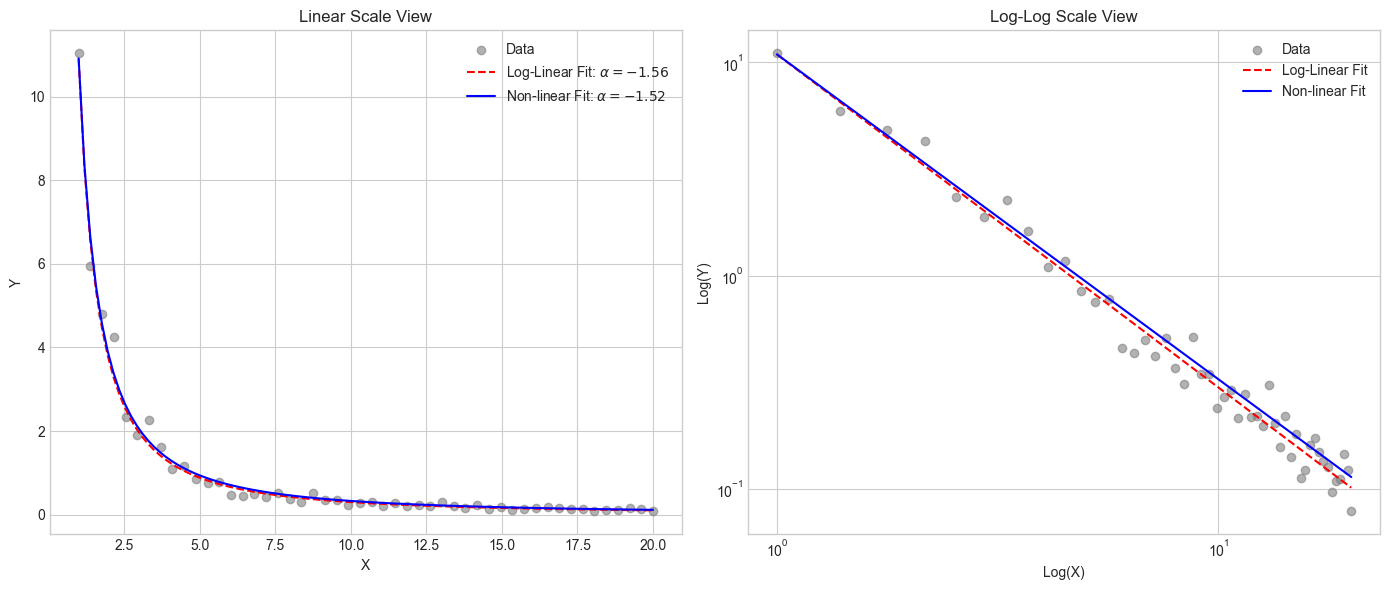

True Params:       C=10.00, alpha=-1.50
Log-Linear Fit:    C=10.90, alpha=-1.56
Non-linear Fit:    C=10.92, alpha=-1.52


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Use a professional style for plotting
plt.style.use('seaborn-v0_8-whitegrid')

def generate_synthetic_data(n_samples: int = 50, alpha: float = -1.5, c: float = 10.0):
    """
    Generates synthetic data following a power law with multiplicative noise.
    Model: y = C * x^alpha * noise
    """
    np.random.seed(42)
    x = np.linspace(1, 20, n_samples)
    
    # Log-normal noise simulates multiplicative error common in power laws
    noise = np.random.lognormal(mean=0, sigma=0.2, size=n_samples)
    y = c * (x ** alpha) * noise
    
    return x, y

def linear_fit_log_space(x, y):
    """
    Approach 1: Linear regression on log-transformed data.
    Minimizes errors in log-space.
    """
    # Transform to log space
    log_x = np.log(x)
    log_y = np.log(y)
    
    # Perform linear fit: log(y) = alpha * log(x) + log(C)
    # np.polyfit returns [slope, intercept] for degree 1
    params = np.polyfit(log_x, log_y, 1)
    alpha_fit = params[0]
    c_fit = np.exp(params[1])
    
    return c_fit, alpha_fit

def nonlinear_fit_original_space(x, y, initial_guess):
    """
    Approach 2: Non-linear least squares on original data.
    Minimizes errors in linear-space (squared residuals).
    """
    # Define the power law function
    def power_law(x, c, alpha):
        return c * np.power(x, alpha)
    
    # curve_fit uses Levenberg-Marquardt algorithm by default
    popt, pcov = curve_fit(power_law, x, y, p0=initial_guess)
    c_fit, alpha_fit = popt
    
    return c_fit, alpha_fit

def main():
    # 1. Prepare Data
    true_alpha = -1.5
    true_c = 10.0
    x_data, y_data = generate_synthetic_data(n_samples=50, alpha=true_alpha, c=true_c)

    # 2. Approach 1: Linear Fit (Log-Log)
    c_lin, alpha_lin = linear_fit_log_space(x_data, y_data)

    # 3. Approach 2: Non-linear Fit (Curve Fit)
    # Note: Use Approach 1's results as initial guesses for Approach 2
    c_nlin, alpha_nlin = nonlinear_fit_original_space(x_data, y_data, initial_guess=[c_lin, alpha_lin])

    # 4. Visualization
    x_plot = np.linspace(min(x_data), max(x_data), 100)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Linear Scale
    ax1.scatter(x_data, y_data, label='Data', color='gray', alpha=0.6)
    ax1.plot(x_plot, c_lin * x_plot**alpha_lin, 'r--', 
             label=f'Log-Linear Fit: $\\alpha={alpha_lin:.2f}$')
    ax1.plot(x_plot, c_nlin * x_plot**alpha_nlin, 'b-', 
             label=f'Non-linear Fit: $\\alpha={alpha_nlin:.2f}$')
    ax1.set_title('Linear Scale View')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.legend()

    # Plot 2: Log-Log Scale
    ax2.scatter(x_data, y_data, label='Data', color='gray', alpha=0.6)
    ax2.plot(x_plot, c_lin * x_plot**alpha_lin, 'r--', label='Log-Linear Fit')
    ax2.plot(x_plot, c_nlin * x_plot**alpha_nlin, 'b-', label='Non-linear Fit')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_title('Log-Log Scale View')
    ax2.set_xlabel('Log(X)')
    ax2.set_ylabel('Log(Y)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"True Params:       C={true_c:.2f}, alpha={true_alpha:.2f}")
    print(f"Log-Linear Fit:    C={c_lin:.2f}, alpha={alpha_lin:.2f}")
    print(f"Non-linear Fit:    C={c_nlin:.2f}, alpha={alpha_nlin:.2f}")


main()